In [30]:
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px


In [11]:
# Carga de archivos y creación de df único.
dfs = []

for subject in ["mathematics", "reading", "science"]:
    df = pd.read_csv(f"../../data/raw/pisa_{subject}_2000_2022.csv")
    df["subject"] = subject
    dfs.append(df)

df_pisa = pd.concat(dfs, ignore_index=True)

In [12]:
# Algunos países tienen 2015 separado del resto en un país con nomenclatura: [nombre del país] (2015). Por ejemplo, Argentina no tiene
# valores en 2015, y Argentina (2015) tiene todo nulo excepto 2015. Se combinan.

# Se elimina el (2015) del nombre de la columna
df_pisa["country"] = df_pisa["country"].str.replace(
    r" \(2015\)$", "", regex=True
)

# Ahora que tienen el mismo nombre, se agrupan y se usa .first(), que coge el primer valor no nulo (que será el de la columna
# original excepto en 2015).
df_pisa = (
    df_pisa
    .groupby(["country", "year", "subject"], as_index=False)
    .first()
)

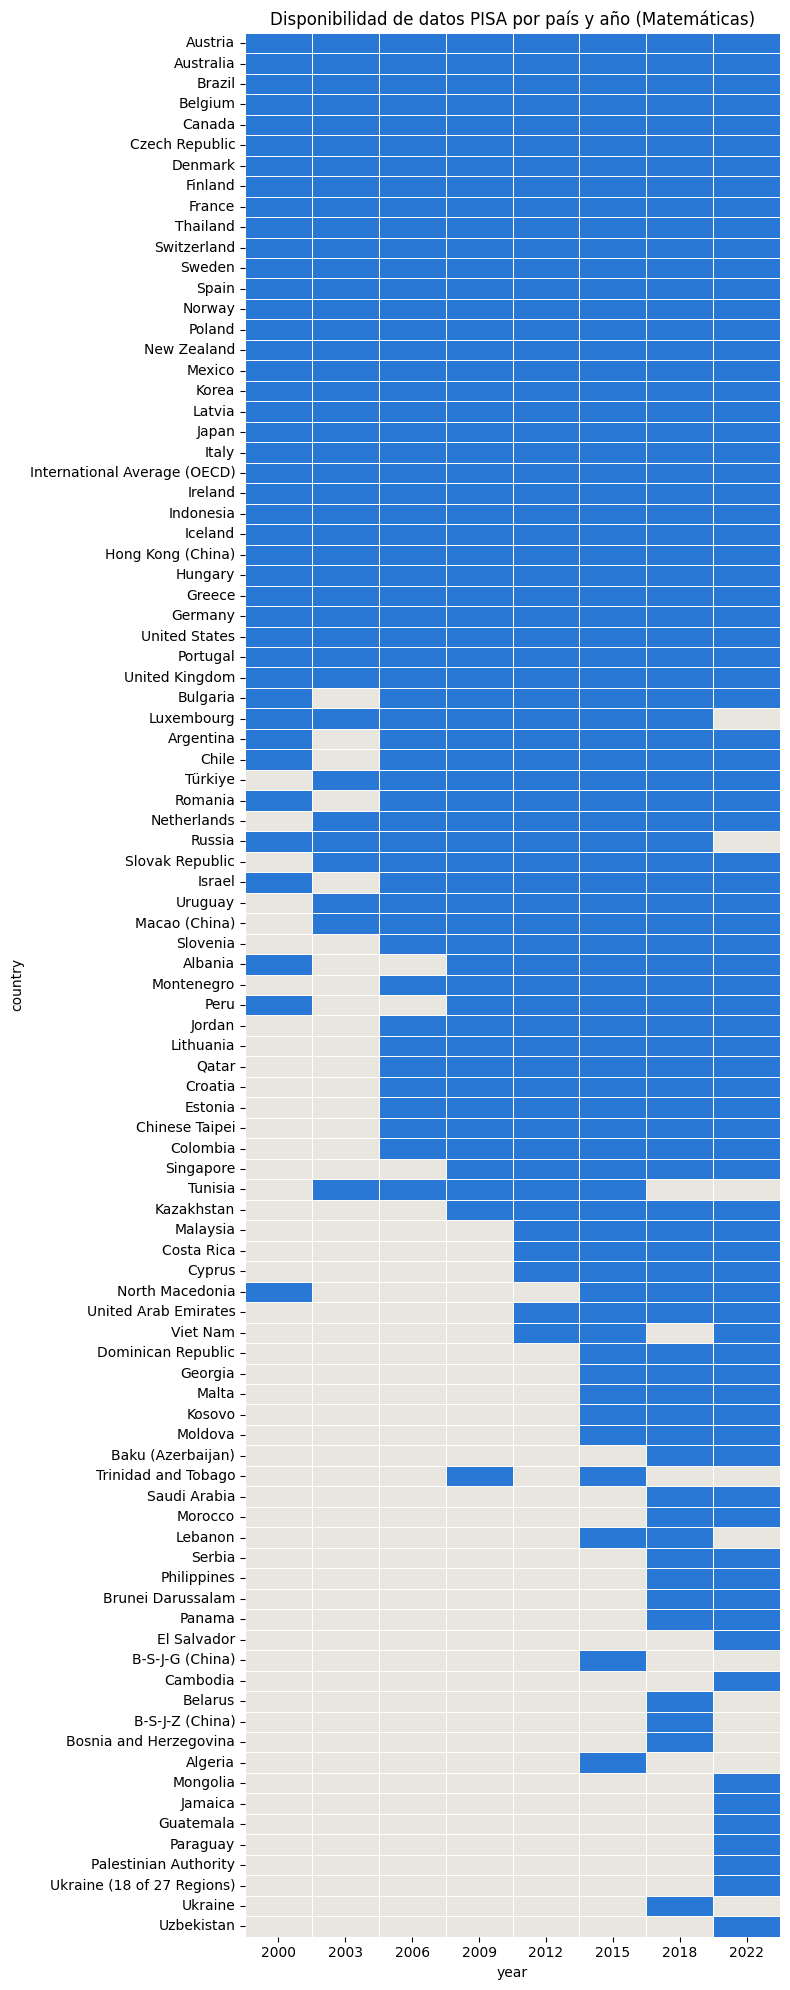

In [13]:
# Participación de países: ver si hay dato en AL MENOS una de las asignaturas por año
participacion = (
df_pisa
.pivot_table(index='country', columns='year', values='average', aggfunc='count')
.fillna(0)
.astype(bool)
)

# Ordenar países por disponibilidad
participacion = participacion.loc[participacion.sum(axis=1).sort_values(ascending=False).index]

# Pintar
fig, ax = plt.subplots(figsize=(8, 20)) # alto porque son ~97 países
sns.heatmap(
participacion,
cmap=['#e8e6df', '#2a78d6'], # gris = no participó, azul = participó
cbar=False,
linewidths=0.5,
linecolor='white',
ax=ax
)
ax.set_title('Disponibilidad de datos PISA por país y año (Matemáticas)')
plt.tight_layout()
plt.show()

Varios países, especialmente aquellos que no son miembros de la OCDE, han participado en pocas ediciones y de manera irregular. Se aplica un filtro para excluir países que apenas han participado. Si se quisiese incluir a todos esos países en la visualización, bastaría con comentar las dos celdas siguientes.

In [14]:
# Asegurar que los años están ordenados
participacion = participacion.sort_index(axis=1)

# Últimas 4 ediciones
ultimas_4 = participacion.columns[-4:]

# Condición 1: participó en las 4 últimas ediciones
cond_ultimas_4 = participacion[ultimas_4].all(axis=1)

# Condición 2: participó en al menos 6 ediciones
cond_6_total = participacion.sum(axis=1) >= 6

# Países que cumplen alguna de las dos
paises_validos = participacion.index[
    cond_ultimas_4 | cond_6_total
]

# Filtrar el dataframe original
df_pisa_filtrado = df_pisa[df_pisa["country"].isin(paises_validos)]

In [15]:
paises_descartados = participacion.index.difference(paises_validos)

print(f"Se conservan {len(paises_validos)} países.")
print(f"Se eliminan {len(paises_descartados)} países.")
print(sorted(paises_descartados))

Se conservan 61 países.
Se eliminan 32 países.
['Algeria', 'B-S-J-G (China)', 'B-S-J-Z (China)', 'Baku (Azerbaijan)', 'Belarus', 'Bosnia and Herzegovina', 'Brunei Darussalam', 'Cambodia', 'Dominican Republic', 'El Salvador', 'Georgia', 'Guatemala', 'Jamaica', 'Kosovo', 'Lebanon', 'Malta', 'Moldova', 'Mongolia', 'Morocco', 'North Macedonia', 'Palestinian Authority', 'Panama', 'Paraguay', 'Philippines', 'Saudi Arabia', 'Serbia', 'Trinidad and Tobago', 'Tunisia', 'Ukraine', 'Ukraine (18 of 27 Regions)', 'Uzbekistan', 'Viet Nam']


In [31]:
paises_ocde = [
    "Australia",
    "Austria",
    "Belgium",
    "Canada",
    "Chile",
    "Colombia",
    "Costa Rica",
    "Czech Republic",
    "Denmark",
    "Estonia",
    "Finland",
    "France",
    "Germany",
    "Greece",
    "Hungary",
    "Iceland",
    "Ireland",
    "Israel",
    "Italy",
    "Japan",
    "Korea",
    "Latvia",
    "Lithuania",
    "Luxembourg",
    "Mexico",
    "Netherlands",
    "New Zealand",
    "Norway",
    "Poland",
    "Portugal",
    "Slovak Republic",
    "Slovenia",
    "Spain",
    "Sweden",
    "Switzerland",
    "Türkiye",
    "United Kingdom",
    "United States"
]

media_ocde = "International Average (OECD)"

lista_paises_completa = df_pisa_filtrado.country.unique().tolist()
lista_paises_completa.remove(media_ocde)

In [18]:
df_pisa_eda = df_pisa_filtrado.copy()

In [26]:
MATERIAS = ["mathematics", "reading", "science"]
COLORES_MATERIAS = {"mathematics": "#636EFA", "reading": "#EF553B", "science": "#00CC96"}

# Paleta de colores adaptada al número de países
def obtener_paleta(n_categorias: int) -> list:
    """
    Devuelve una lista de colores con al menos `n_categorias` colores
    distinguibles, para evitar que px.line() repita colores en color='country'
    cuando hay muchos países (la paleta por defecto de Plotly solo tiene 10).

    Estrategia:
    - Hasta 10 países: paleta por defecto de Plotly (la más limpia).
    - Hasta 26 países: paleta cualitativa 'Alphabet' (26 colores distinguibles).
    - Más de 26 países: paleta continua muestreada (colores ya no 100%
      distinguibles a simple vista, pero sin repeticiones).

    Parameters
    ----------
    n_categorias : int
        Número de países (u otras categorías) a colorear.

    Returns
    -------
    list[str]
        Lista de colores en formato hexadecimal/rgb.
    """
    if n_categorias <= 10:
        return px.colors.qualitative.Plotly
    elif n_categorias <= 26:
        return px.colors.qualitative.Alphabet
    else:
        return px.colors.sample_colorscale(
            "turbo", [i / (n_categorias - 1) for i in range(n_categorias)]
        )


# Preparar los datos de un conjunto de países (incluye media 3 materias)
def preparar_evolucion(
    df: pd.DataFrame,
    paises: list,
    metrica: str = "average",
    incluir_media: bool = True,
) -> pd.DataFrame:
    """
    Filtra y ordena los datos de evolución temporal para uno o varios países,
    y opcionalmente añade una "materia" sintética 'average_3subjects' con la
    media de mathematics/reading/science para cada país-año (solo si las tres
    materias tienen dato ese año; si falta alguna, no se calcula la media
    para evitar sesgar el promedio).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame en formato largo con columnas year, country, subject, metric.
    paises : list[str]
        Lista de nombres de país EXACTOS (usar buscar_paises si hay dudas).
    metric : str, default 'average'
        Columna métrica a analizar (p.ej. 'average', 'p50', 'std_dev', ...).
    incluir_media : bool, default True
        Si True, añade filas con subject='average_3subjects'.

    Returns
    -------
    pd.DataFrame
        Columnas: year, country, subject, metric.
    """
    faltantes = set(paises) - set(df["country"].unique())
    if faltantes:
        raise ValueError(
            f"País(es) no encontrados: {faltantes}. "
            f"Usa buscar_paises(df, 'texto') para localizar el nombre exacto."
        )

    df_filtrado = df[df["country"].isin(paises) & df["subject"].isin(MATERIAS)].copy()
    df_filtrado = df_filtrado.dropna(subset=[metrica])
    df_filtrado = df_filtrado[["year", "country", "subject", metrica]]

    if incluir_media:
        pivot = df_filtrado.pivot_table(
            index=["year", "country"], columns="subject", values=metrica
        )
        # Solo calcular la media donde están las 3 materias disponibles
        pivot_completo = pivot.dropna(subset=MATERIAS)
        media = pivot_completo[MATERIAS].mean(axis=1).reset_index()
        media.columns = ["year", "country", metrica]
        media["subject"] = "average_3subjects"
        media = media[["year", "country", "subject", metrica]]

        df_filtrado = pd.concat([df_filtrado, media], ignore_index=True)

    return df_filtrado.sort_values(["country", "subject", "year"])



# Evolución individual de un país (3 materias + media)
def plot_evolucion_pais(
    df: pd.DataFrame,
    pais: str,
    metrica: str = "average",
    mostrar_media: bool = True,
) -> go.Figure:
    """
    Muestra la evolución temporal de un único país: las tres materias
    (mathematics, reading, science) y, opcionalmente, la media de las tres.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame en formato largo (year, country, subject, metric).
    pais : str
        Nombre exacto del país (usar buscar_paises si hay dudas).
    metric : str, default 'average'
        Métrica a representar.
    mostrar_media : bool, default True
        Si True, añade la línea de la media de las 3 materias.

    Returns
    -------
    go.Figure
    """
    datos = preparar_evolucion(df, [pais], metrica=metrica, incluir_media=mostrar_media)

    fig = go.Figure()

    for subject in MATERIAS:
        sub = datos[datos["subject"] == subject]
        if sub.empty:
            continue
        fig.add_trace(
            go.Scatter(
                x=sub["year"], y=sub[metrica],
                mode="lines+markers",
                name=subject.capitalize(),
                line=dict(color=COLORES_MATERIAS.get(subject)),
            )
        )

    if mostrar_media:
        sub = datos[datos["subject"] == "average_3subjects"]
        if not sub.empty:
            fig.add_trace(
                go.Scatter(
                    x=sub["year"], y=sub[metrica],
                    mode="lines+markers",
                    name="Media (3 materias)",
                    line=dict(color="black", dash="dash", width=3),
                )
            )

    fig.update_layout(
        title=f"Evolución PISA — {pais} ({metrica})",
        xaxis_title="Año", yaxis_title=metrica,
        legend_title="Materia",
        template="plotly_white", hovermode="x unified",
    )
    return fig


# Comparación entre países para UNA materia (o la media)
def plot_comparar_paises(
    df: pd.DataFrame,
    paises: list,
    materia: str = "mathematics",
    metrica: str = "average",
) -> go.Figure:
    """
    Compara la evolución temporal de varios países para una materia,
    o para la media de las 3 (subject='average_3subjects').

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame en formato largo.
    paises : list[str]
        Lista de países a comparar (nombres exactos).
    subject : str, default 'mathematics'
        'mathematics', 'reading', 'science' o 'average_3subjects'.
    metric : str, default 'average'
        Métrica a representar.

    Returns
    -------
    go.Figure
    """
    incluir_media = materia == "average_3subjects"
    datos = preparar_evolucion(df, paises, metrica=metrica, incluir_media=incluir_media)
    datos = datos[datos["subject"] == materia]

    titulo_subject = "Media (3 materias)" if incluir_media else materia.capitalize()
    paleta = obtener_paleta(datos["country"].nunique())

    fig = px.line(
        datos, x="year", y=metrica, color="country", markers=True,
        template="plotly_white",
        color_discrete_sequence=paleta,
        title=f"Comparativa entre países — {titulo_subject} ({metrica})",
    )
    fig.update_layout(xaxis_title="Año", yaxis_title=metrica, legend_title="País", hovermode="x unified")
    return fig


# Comparación entre países, facetado por materia (+ media)
def plot_comparar_paises_todas_materias(
    df: pd.DataFrame,
    paises: list,
    metrica: str = "average",
    incluir_media: bool = True,
) -> go.Figure:
    """
    Compara la evolución temporal de varios países en las tres materias
    a la vez (subplots por materia), y opcionalmente añade un panel más
    con la media de las 3.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame en formato largo.
    paises : list[str]
        Lista de países a comparar (nombres exactos).
    metric : str, default 'average'
        Métrica a representar.
    incluir_media : bool, default True
        Si True, añade un panel adicional 'average_3subjects'.

    Returns
    -------
    go.Figure
    """
    datos = preparar_evolucion(df, paises, metrica=metrica, incluir_media=incluir_media)

    orden = MATERIAS + (["average_3subjects"] if incluir_media else [])
    datos = datos[datos["subject"].isin(orden)]
    paleta = obtener_paleta(datos["country"].nunique())

    fig = px.line(
        datos, x="year", y=metrica, color="country", facet_col="subject",
        markers=True, template="plotly_white",
        category_orders={"subject": orden},
        color_discrete_sequence=paleta,
        title=f"Comparativa entre países por materia ({metrica})",
    )
    fig.update_layout(legend_title="País", hovermode="x unified")
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1].replace("_", " ").capitalize()))
    return fig

In [27]:
evo_fig_1 = plot_evolucion_pais(df_pisa_eda, "Spain")
evo_fig_1.show()

In [28]:
comp_fig_1 = plot_comparar_paises(df=df_pisa_eda, paises=["Spain", media_ocde], materia="mathematics", metrica="p90") # La métrica es 'p90' en lugar de la media. p90 = top 10% de alumnos
comp_fig_1.show()

In [29]:
comp_all_fig_1 = plot_comparar_paises_todas_materias(df=df_pisa_eda, paises=["Spain", "Portugal", "France", "Italy", "Germany"])
comp_all_fig_1.show()

In [33]:
lista_paises = random.sample(paises_ocde, 4) # Utilizar lista_paises_completa para incluir todos los países.
lista_paises.append(media_ocde) # OPCIONAL: nos aseguramos de que la media de la OCDE siempre esté presente.

random_sample_fig = plot_comparar_paises_todas_materias(df_pisa_eda, lista_paises)
random_sample_fig.show()